# Clustering Stratifié pour le Split Train / Test

**Objectif** : garantir un split train/test **représentatif** du stock résidentiel en effectuant un clustering
indépendant sur chaque groupe métier, puis en agrégeant les labels pour construire un stratum composite.

**Pipeline** :
1. Clustering KMeans par groupe de features (7 groupes)
2. Analyse de chaque clustering (elbow, silhouette, centroïdes)
3. Agrégation → stratum composite
4. `train_test_split(stratify=stratum)` équilibré
5. Sauvegarde des indices

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

ROOT           = Path().resolve().parent.parent
DATA_PROCESSED = ROOT / 'data' / 'processed'

RANDOM_STATE = 42
TEST_SIZE    = 0.20

print('Libs OK')

Libs OK


## 1. Chargement des données

In [3]:
X = pd.read_parquet(DATA_PROCESSED / 'X.parquet')
Y = pd.read_parquet(DATA_PROCESSED / 'Y.parquet')

print(f'X : {X.shape}  |  Y : {Y.shape}')
print(f'NaN dans X : {X.isna().sum().sum()}')
X.dtypes.value_counts()

X : (549971, 110)  |  Y : (549971, 5)
NaN dans X : 0


int64      35
float64    29
float32    19
Int8       18
int8        9
Name: count, dtype: int64

## 2. Définition des groupes de features

In [4]:
GROUPES = {

    'G1_SocioEco': [
        'in.income', 'in.federal_poverty_level',
        'in.area_median_income', 'in.state_metro_median_income',
        'in.tenure', 'in.household_has_tribal_persons', 'in.aiannh_area',
        'in.electric_panel_service_rating..a',
        'in.electric_panel_breaker_space_total_count',
        'in.has_pv', 'in.pv_system_size',
        'in.electric_vehicle_charge_at_home',
        'in.electric_vehicle_charger', 'in.electric_vehicle_miles_traveled',
    ],

    'G2_Occupants': [
        'in.occupants', 'in.bedrooms', 'in.vacancy_status',
        'in.usage_level', 'in.corridor', 'in.hot_water_fixtures',
    ],

    'G3_Meteo': [
        'in.weather_file_latitude', 'in.weather_file_longitude',
    ],

    'G4_Enveloppe': [
        'in.insulation_ceiling', 'in.insulation_wall',
        'in.insulation_roof',   'in.insulation_floor',
        'in.insulation_foundation_wall',
        'in.slab_perimeter_r',  'in.slab_under_r',
        'in.air_leakage_to_outside_ach50',
        'in.window_ufactor', 'in.window_shgc', 'in.window_front',
        'in.geometry_floor_area', 'in.geometry_stories',
        'in.geometry_attic_type', 'in.geometry_foundation_type',
        'in.geometry_garage', 'in.vintage', 'in.roof_material',
        'in.orientation_sin', 'in.orientation_cos',
        'in.wall_exterior_finish_r',
        'in.wall_finish_dark', 'in.wall_finish_brick', 'in.wall_finish_none',
        'in.wall_finish_shingle', 'in.wall_finish_stucco',
        'in.wall_finish_vinyl', 'in.wall_finish_wood',
        'in.horiz_loc_Middle', 'in.horiz_loc_Right',
        'in.neighbor_distance_ft', 'in.neighbor_both_sides',
    ],

    'G5_Systemes': [
        'in.hvac_has_ducts', 'in.duct_leakage', 'in.duct_insulation',
        'in.duct_location_int', 'in.hvac_cooling_efficiency',
        'in.hvac_cooling_partial_space_conditioning',
        'in.hvac_has_zonal_electric_heating',
        'in.cooling_setpoint', 'in.cooling_setpoint_has_offset',
        'in.cooling_setpoint_offset_magnitude',
        'in.heating_setpoint', 'in.heating_setpoint_has_offset',
        'in.heating_setpoint_offset_magnitude',
        'in.water_heater_efficiency', 'in.water_heater_in_unit',
        'in.water_heater_technology_indirect',
        'in.water_heater_technology_storage',
        'in.water_heater_technology_tankless',
        'in.water_heater_fuel_fuel_oil', 'in.water_heater_fuel_natural_gas',
        'in.water_heater_fuel_propane',
        'in.water_heater_location_semi_conditioned',
        'in.water_heater_location_unconditioned',
        'in.dishwasher_kwh', 'in.has_dishwasher',
    ],

    'G6_UsagesElec': [
        'in.clothes_dryer_efficiency', 'in.clothes_dryer_has',
        'in.clothes_dryer_electric', 'in.clothes_dryer_gas',
        'in.clothes_washer_efficiency', 'in.clothes_washer_has',
        'in.refrigerator_ef', 'in.refrigerator_has',
        'in.lighting_efficiency',
        'in.misc_extra_refrigerator_ef', 'in.misc_extra_refrigerator_has',
        'in.misc_freezer_ef',
        'in.misc_gas_fireplace_present', 'in.misc_gas_grill_present',
        'in.misc_gas_lighting_present',
        'in.has_hot_tub', 'in.hot_tub_electric', 'in.misc_hot_tub_gas',
        'in.has_pool', 'in.pool_heater_present',
        'in.pool_heater_electric', 'in.pool_heater_gas',
        'in.has_well_pump', 'in.has_ceiling_fan', 'in.ceiling_fan_used',
    ],

    'G7_BlancBrun': [
        'in.plug_loads', 'in.plug_load_diversity',
        'in.clothes_dryer_usage_level', 'in.refrigerator_usage_level',
    ],
}

# Vérification : toutes les colonnes existent dans X
all_cols = [c for cols in GROUPES.values() for c in cols]
manquantes = [c for c in all_cols if c not in X.columns]
print(f'Colonnes définies : {len(all_cols)}  |  Manquantes : {manquantes}')
print()
for g, cols in GROUPES.items():
    cols_ok = [c for c in cols if c in X.columns]
    print(f'{g:20s} : {len(cols_ok):3d} features')

Colonnes définies : 108  |  Manquantes : ['in.has_pv', 'in.slab_perimeter_r', 'in.slab_under_r', 'in.window_ufactor', 'in.window_shgc', 'in.wall_exterior_finish_r', 'in.water_heater_in_unit', 'in.pool_heater_present']

G1_SocioEco          :  13 features
G2_Occupants         :   6 features
G3_Meteo             :   2 features
G4_Enveloppe         :  27 features
G5_Systemes          :  24 features
G6_UsagesElec        :  24 features
G7_BlancBrun         :   4 features


## 3. Fonctions utilitaires

In [5]:
def elbow_silhouette(X_scaled, k_range=range(2, 9), name='', sample_sil=20_000):
    """Calcule inertie et silhouette pour chaque k. Retourne (inertias, silhouettes)."""
    inertias, silhouettes = [], []
    idx_sample = np.random.choice(len(X_scaled), min(sample_sil, len(X_scaled)), replace=False)
    X_sil = X_scaled[idx_sample]

    for k in k_range:
        km = MiniBatchKMeans(n_clusters=k, random_state=RANDOM_STATE,
                             batch_size=10_000, n_init=3)
        labels_all  = km.fit_predict(X_scaled)
        labels_sil  = labels_all[idx_sample]
        inertias.append(km.inertia_)
        sil = silhouette_score(X_sil, labels_sil, sample_size=min(5000, len(X_sil)))
        silhouettes.append(sil)
        print(f'  k={k}  inertie={km.inertia_:,.0f}  silhouette={sil:.3f}')

    return list(k_range), inertias, silhouettes


def plot_elbow(k_range, inertias, silhouettes, name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.5))
    ax1.plot(k_range, inertias, 'o-', color='steelblue')
    ax1.set(title=f'{name} — Elbow (inertie)', xlabel='k', ylabel='Inertie')
    ax1.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax2.plot(k_range, silhouettes, 's-', color='coral')
    ax2.set(title=f'{name} — Silhouette', xlabel='k', ylabel='Score silhouette')
    ax2.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    plt.tight_layout()
    plt.show()


def cluster_group(X_df, cols, k, name):
    """Scale + KMeans sur un groupe. Retourne (labels, scaler, model, X_scaled)."""
    cols = [c for c in cols if c in X_df.columns]
    X_g  = X_df[cols].astype(float).values
    sc   = StandardScaler()
    Xs   = sc.fit_transform(X_g)
    km   = MiniBatchKMeans(n_clusters=k, random_state=RANDOM_STATE,
                           batch_size=10_000, n_init=5, max_iter=300)
    labels = km.fit_predict(Xs)
    print(f'{name} | k={k} | inertie={km.inertia_:,.0f}')
    print(pd.Series(labels).value_counts().sort_index().to_string())
    return labels, sc, km, Xs


def analyse_cluster(X_df, cols, labels, km, sc, name, n_top=8):
    """Heatmap des centroïdes (features les plus discriminantes)."""
    cols   = [c for c in cols if c in X_df.columns]
    k      = km.n_clusters
    # Centroïdes en espace original
    cents  = sc.inverse_transform(km.cluster_centers_)
    df_c   = pd.DataFrame(cents, columns=cols)

    # Variance entre clusters (pour trier les features les plus discriminantes)
    var    = df_c.var(axis=0).sort_values(ascending=False)
    top_f  = var.index[:n_top].tolist()

    # Normaliser chaque feature entre 0 et 1 pour la heatmap
    df_plot = df_c[top_f].copy()
    df_plot = (df_plot - df_plot.min()) / (df_plot.max() - df_plot.min() + 1e-9)

    sizes = pd.Series(labels).value_counts().sort_index()
    row_labels = [f'Cluster {i} (n={sizes[i]:,})' for i in range(k)]

    fig, ax = plt.subplots(figsize=(max(10, len(top_f)*1.1), 3 + k*0.5))
    sns.heatmap(df_plot.values, xticklabels=[c.replace('in.','') for c in top_f],
                yticklabels=row_labels, annot=df_c[top_f].values.round(2),
                fmt='.2f', cmap='YlOrRd', ax=ax, linewidths=0.4)
    ax.set_title(f'{name} — Centroïdes (top {len(top_f)} features discriminantes)', pad=10)
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    plt.show()

print('Fonctions chargées.')

Fonctions chargées.


---
## 4. Clustering par groupe
### G1 — Variables Socio-Économiques

Elbow / silhouette pour G1_SocioEco (13 features) :
  k=2  inertie=5,566,762  silhouette=0.274
  k=3  inertie=5,247,738  silhouette=0.145
  k=4  inertie=4,694,356  silhouette=0.160
  k=5  inertie=4,421,513  silhouette=0.161
  k=6  inertie=4,088,768  silhouette=0.160


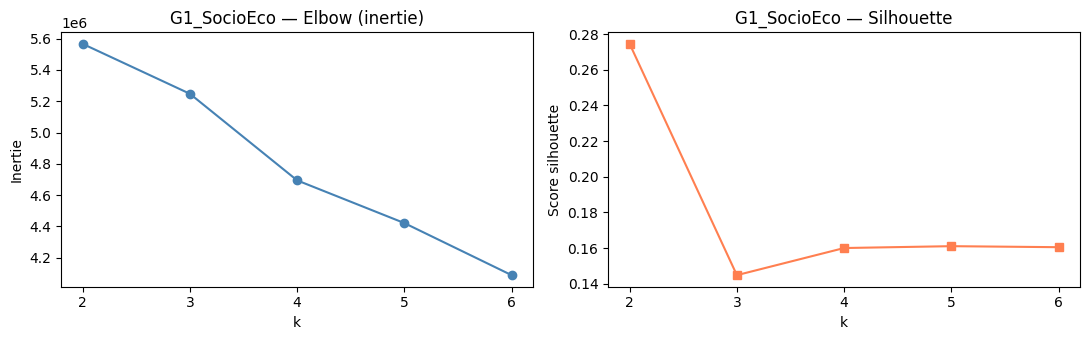

In [6]:
g = 'G1_SocioEco'
cols_g1 = GROUPES[g]
cols_g1 = [c for c in cols_g1 if c in X.columns]

Xs_g1 = StandardScaler().fit_transform(X[cols_g1].astype(float).values)

print(f'Elbow / silhouette pour {g} ({len(cols_g1)} features) :')
k_range, inertias, sils = elbow_silhouette(Xs_g1, range(2, 7), name=g)
plot_elbow(k_range, inertias, sils, g)

G1_SocioEco | k=3 | inertie=5,264,459
0    255003
1    147875
2    147093


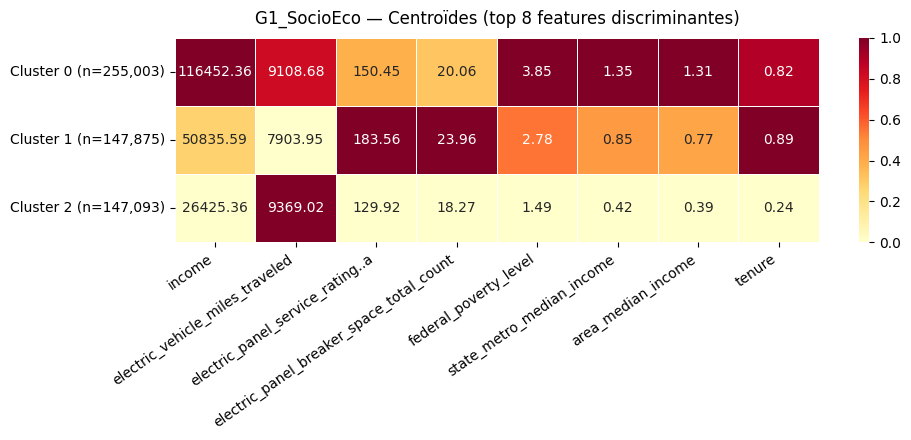

In [7]:
K_G1 = 3   # ← ajuster selon elbow

labels_g1, sc_g1, km_g1, Xs_g1 = cluster_group(X, cols_g1, K_G1, g)
analyse_cluster(X, cols_g1, labels_g1, km_g1, sc_g1, g)

### G2 — Variables Occupants

Elbow / silhouette pour G2_Occupants (6 features) :
  k=2  inertie=2,620,793  silhouette=0.225
  k=3  inertie=1,980,692  silhouette=0.296
  k=4  inertie=1,471,215  silhouette=0.355
  k=5  inertie=1,350,482  silhouette=0.288
  k=6  inertie=1,159,714  silhouette=0.313


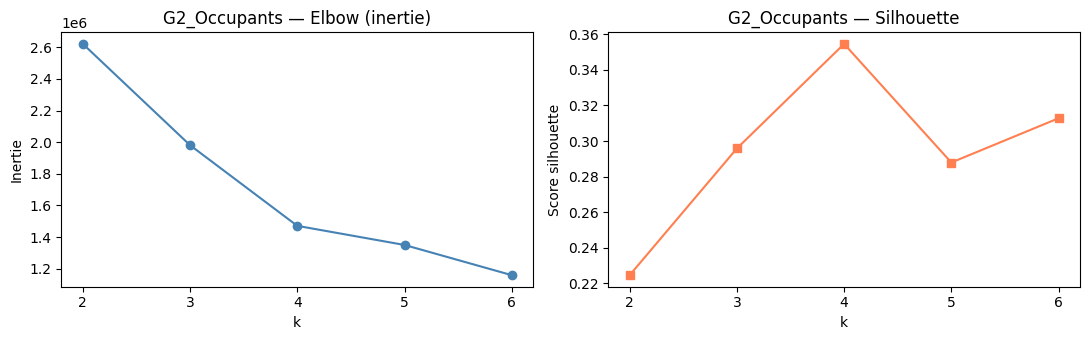

In [8]:
g = 'G2_Occupants'
cols_g2 = [c for c in GROUPES[g] if c in X.columns]

Xs_g2_tmp = StandardScaler().fit_transform(X[cols_g2].astype(float).values)
print(f'Elbow / silhouette pour {g} ({len(cols_g2)} features) :')
k_range, inertias, sils = elbow_silhouette(Xs_g2_tmp, range(2, 7), name=g)
plot_elbow(k_range, inertias, sils, g)

G2_Occupants | k=3 | inertie=1,935,244
0    124161
1    359173
2     66637


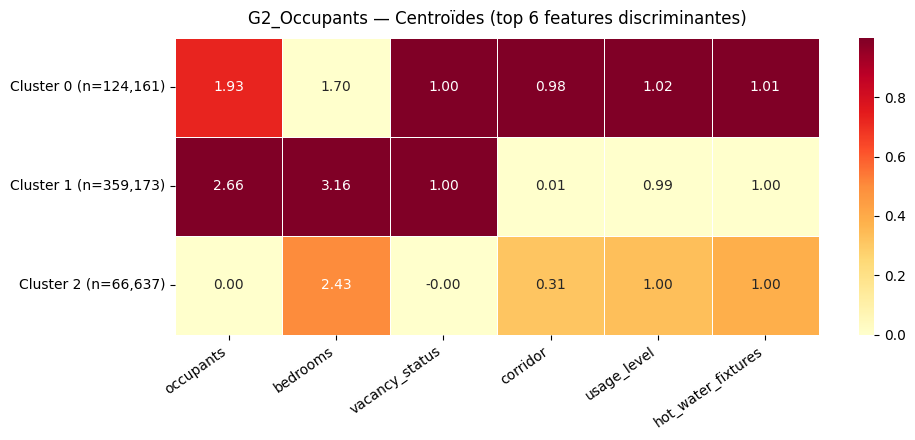

In [9]:
K_G2 = 3   # ← ajuster

labels_g2, sc_g2, km_g2, Xs_g2 = cluster_group(X, cols_g2, K_G2, g)
analyse_cluster(X, cols_g2, labels_g2, km_g2, sc_g2, g)

### G3 — Variables Météo

Elbow / silhouette pour G3_Meteo (2 features) :
  k=2  inertie=683,733  silhouette=0.460
  k=3  inertie=363,291  silhouette=0.495
  k=4  inertie=271,357  silhouette=0.508
  k=5  inertie=221,335  silhouette=0.442
  k=6  inertie=174,128  silhouette=0.449
  k=7  inertie=158,682  silhouette=0.460


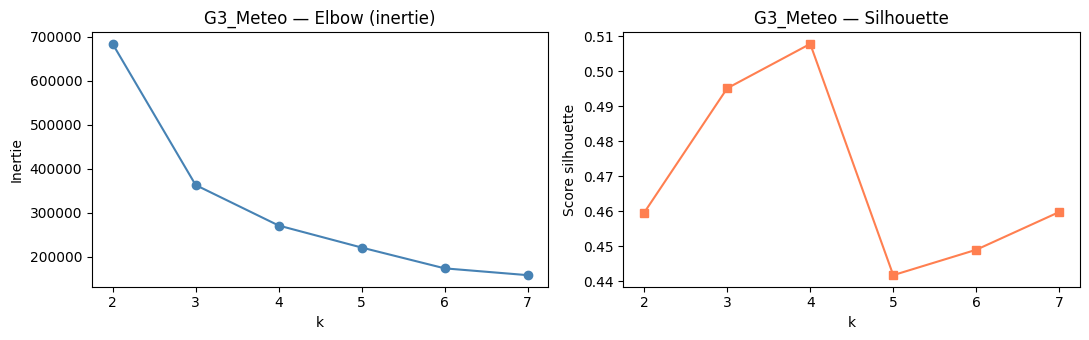

In [10]:
g = 'G3_Meteo'
cols_g3 = [c for c in GROUPES[g] if c in X.columns]

Xs_g3_tmp = StandardScaler().fit_transform(X[cols_g3].astype(float).values)
print(f'Elbow / silhouette pour {g} ({len(cols_g3)} features) :')
k_range, inertias, sils = elbow_silhouette(Xs_g3_tmp, range(2, 8), name=g)
plot_elbow(k_range, inertias, sils, g)

G3_Meteo | k=5 | inertie=221,298
0    153604
1    160757
2     86203
3     27848
4    121559


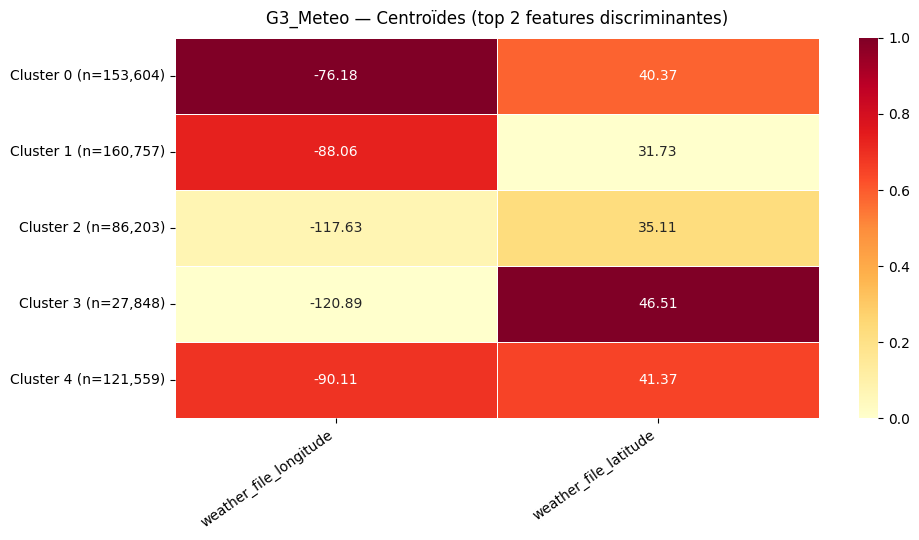

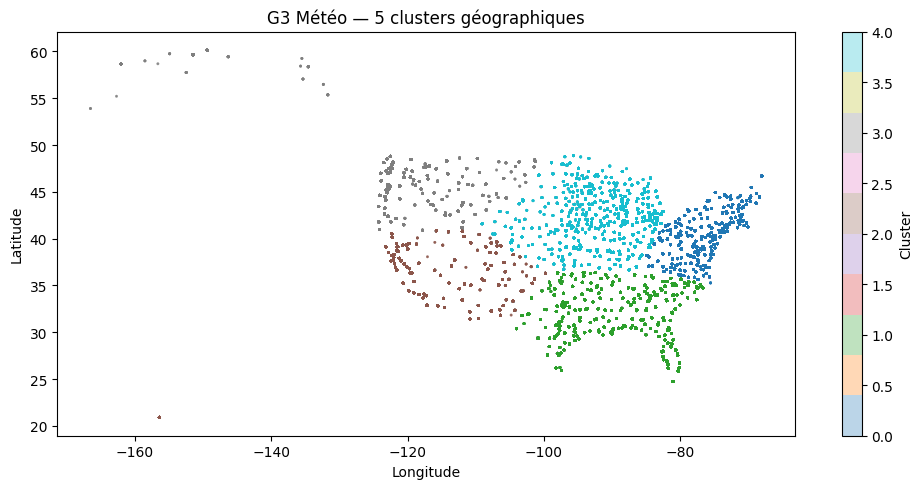

In [11]:
K_G3 = 5   # ← zones géographiques US (NE/SE/MW/SW/NW)

labels_g3, sc_g3, km_g3, Xs_g3 = cluster_group(X, cols_g3, K_G3, g)
analyse_cluster(X, cols_g3, labels_g3, km_g3, sc_g3, g, n_top=2)

# Visualisation géographique
fig, ax = plt.subplots(figsize=(10, 5))
scatter = ax.scatter(
    X['in.weather_file_longitude'], X['in.weather_file_latitude'],
    c=labels_g3, cmap='tab10', s=1, alpha=0.3
)
ax.set(xlabel='Longitude', ylabel='Latitude', title=f'G3 Météo — {K_G3} clusters géographiques')
plt.colorbar(scatter, ax=ax, label='Cluster')
plt.tight_layout()
plt.show()

### G4 — Enveloppe Thermique

Elbow / silhouette pour G4_Enveloppe (27 features) :
  k=2  inertie=13,758,798  silhouette=0.068
  k=3  inertie=12,556,813  silhouette=0.086
  k=4  inertie=12,012,425  silhouette=0.069
  k=5  inertie=11,540,376  silhouette=0.106
  k=6  inertie=11,084,749  silhouette=0.113
  k=7  inertie=10,872,694  silhouette=0.107


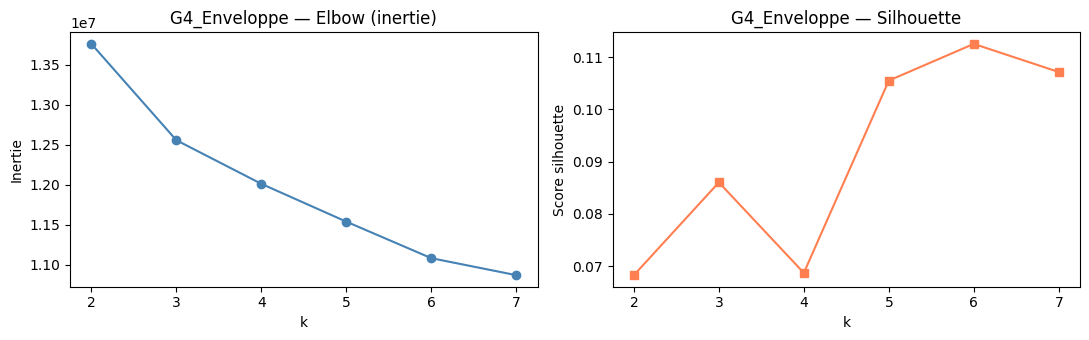

In [12]:
g = 'G4_Enveloppe'
cols_g4 = [c for c in GROUPES[g] if c in X.columns]

Xs_g4_tmp = StandardScaler().fit_transform(X[cols_g4].astype(float).values)
print(f'Elbow / silhouette pour {g} ({len(cols_g4)} features) :')
k_range, inertias, sils = elbow_silhouette(Xs_g4_tmp, range(2, 8), name=g)
plot_elbow(k_range, inertias, sils, g)

G4_Enveloppe | k=4 | inertie=12,019,290
0    139406
1    121861
2    142322
3    146382


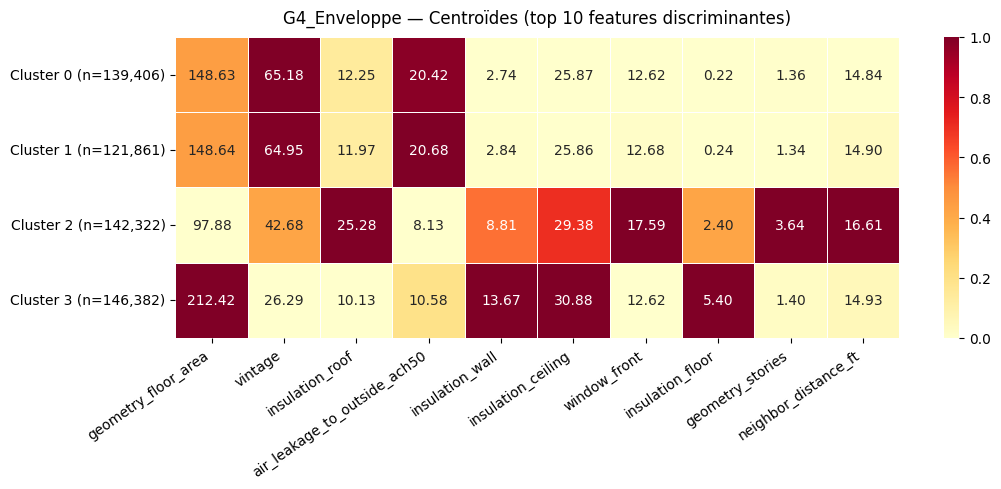

In [13]:
K_G4 = 4   # ← ajuster (ex: vieux mal isolé / vieux rénové / récent standard / récent performant)

labels_g4, sc_g4, km_g4, Xs_g4 = cluster_group(X, cols_g4, K_G4, g)
analyse_cluster(X, cols_g4, labels_g4, km_g4, sc_g4, g, n_top=10)

### G5 — Systèmes Énergétiques

Elbow / silhouette pour G5_Systemes (24 features) :
  k=2  inertie=12,086,952  silhouette=0.139
  k=3  inertie=11,446,161  silhouette=0.135
  k=4  inertie=10,608,972  silhouette=0.094
  k=5  inertie=9,844,566  silhouette=0.131
  k=6  inertie=9,184,818  silhouette=0.103
  k=7  inertie=8,664,326  silhouette=0.123


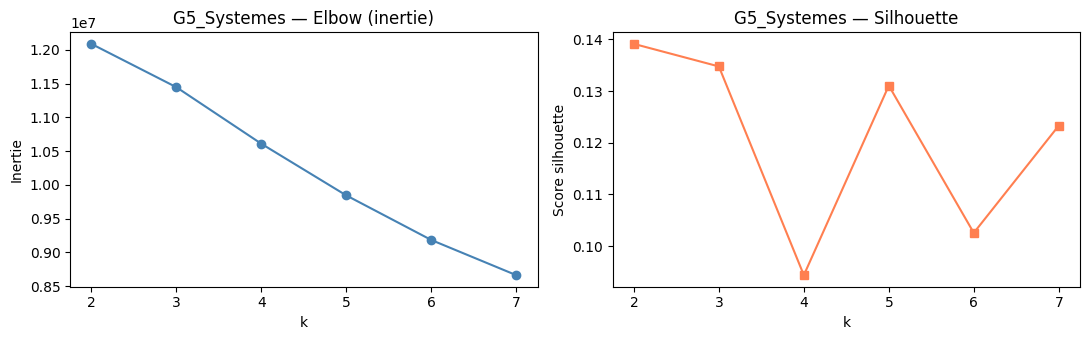

In [14]:
g = 'G5_Systemes'
cols_g5 = [c for c in GROUPES[g] if c in X.columns]

Xs_g5_tmp = StandardScaler().fit_transform(X[cols_g5].astype(float).values)
print(f'Elbow / silhouette pour {g} ({len(cols_g5)} features) :')
k_range, inertias, sils = elbow_silhouette(Xs_g5_tmp, range(2, 8), name=g)
plot_elbow(k_range, inertias, sils, g)

G5_Systemes | k=4 | inertie=10,609,460
0    145049
1    132309
2    122013
3    150600


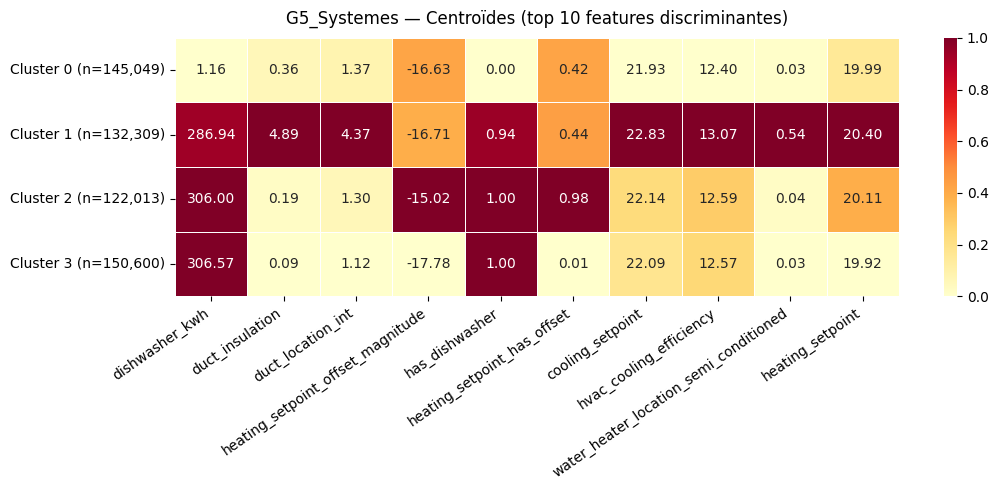

In [15]:
K_G5 = 4   # ← ajuster (ex: gaz/élec + efficace/standard)

labels_g5, sc_g5, km_g5, Xs_g5 = cluster_group(X, cols_g5, K_G5, g)
analyse_cluster(X, cols_g5, labels_g5, km_g5, sc_g5, g, n_top=10)

### G6 — Classification des Usages Électriques

Elbow / silhouette pour G6_UsagesElec (24 features) :
  k=2  inertie=11,065,698  silhouette=0.265
  k=3  inertie=10,491,265  silhouette=0.274
  k=4  inertie=9,511,400  silhouette=0.305
  k=5  inertie=8,559,171  silhouette=0.243
  k=6  inertie=8,087,642  silhouette=0.218


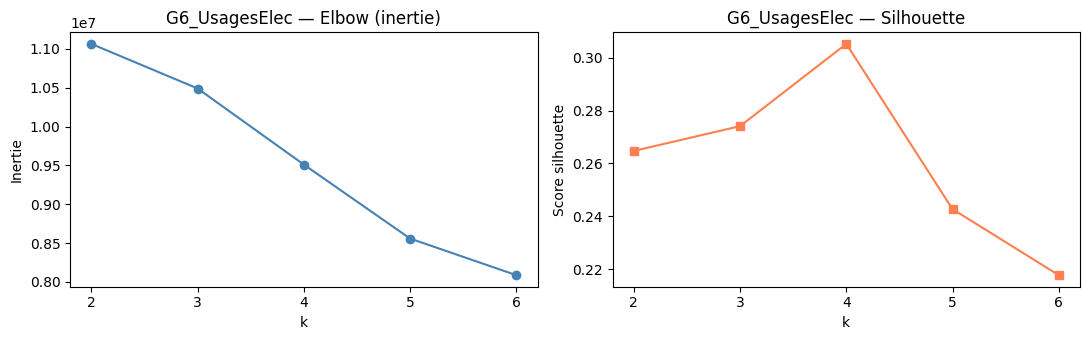

In [16]:
g = 'G6_UsagesElec'
cols_g6 = [c for c in GROUPES[g] if c in X.columns]

Xs_g6_tmp = StandardScaler().fit_transform(X[cols_g6].astype(float).values)
print(f'Elbow / silhouette pour {g} ({len(cols_g6)} features) :')
k_range, inertias, sils = elbow_silhouette(Xs_g6_tmp, range(2, 7), name=g)
plot_elbow(k_range, inertias, sils, g)

G6_UsagesElec | k=3 | inertie=10,491,074
0      6600
1    445257
2     98114


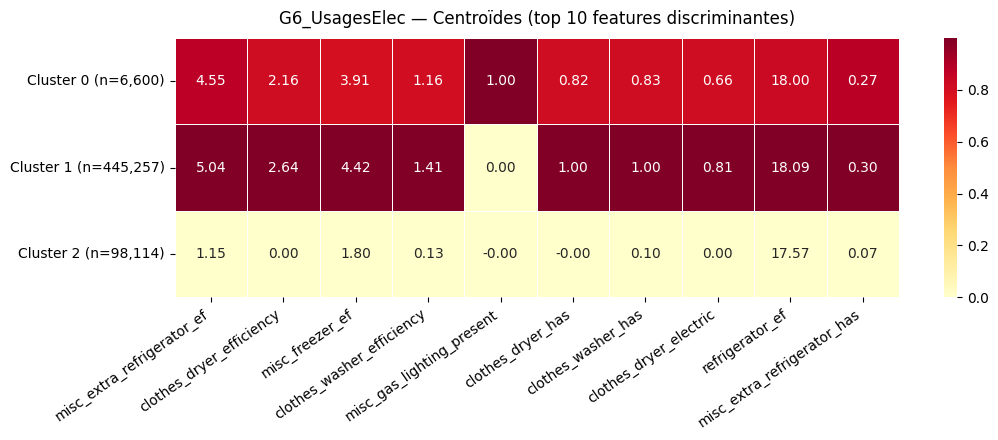

In [17]:
K_G6 = 3   # ← ajuster (ex: équipement basique / standard / premium)

labels_g6, sc_g6, km_g6, Xs_g6 = cluster_group(X, cols_g6, K_G6, g)
analyse_cluster(X, cols_g6, labels_g6, km_g6, sc_g6, g, n_top=10)

### G7 — Part des Usages Blanc et Brun

Elbow / silhouette pour G7_BlancBrun (4 features) :
  k=2  inertie=993,815  silhouette=0.574
  k=3  inertie=549,971  silhouette=0.604
  k=4  inertie=381,513  silhouette=0.599
  k=5  inertie=296,613  silhouette=0.586


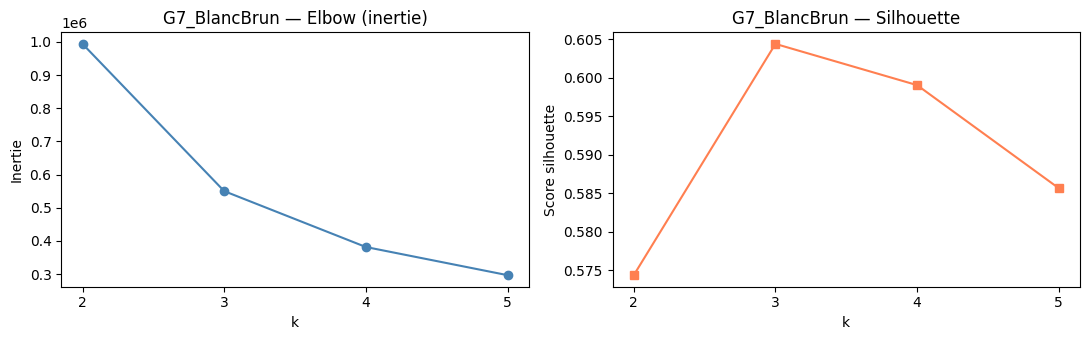

In [18]:
g = 'G7_BlancBrun'
cols_g7 = [c for c in GROUPES[g] if c in X.columns]

Xs_g7_tmp = StandardScaler().fit_transform(X[cols_g7].astype(float).values)
print(f'Elbow / silhouette pour {g} ({len(cols_g7)} features) :')
k_range, inertias, sils = elbow_silhouette(Xs_g7_tmp, range(2, 6), name=g)
plot_elbow(k_range, inertias, sils, g)

G7_BlancBrun | k=3 | inertie=549,972
0    274985
1    137495
2    137491


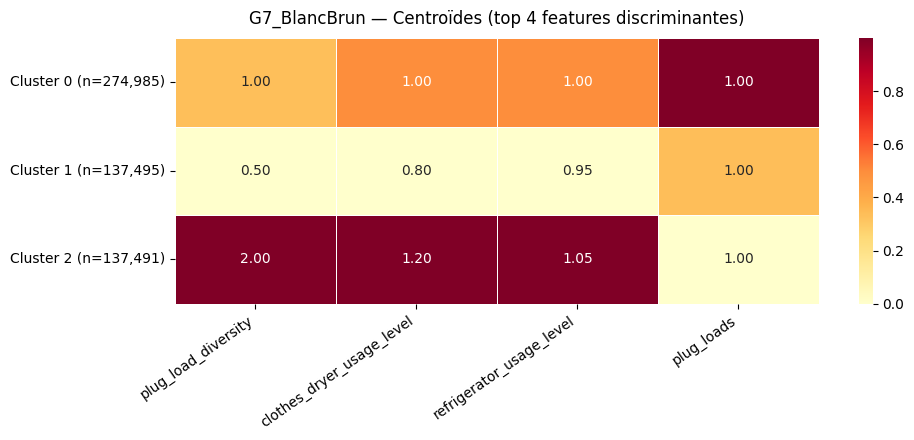

In [19]:
K_G7 = 3   # ← ajuster

labels_g7, sc_g7, km_g7, Xs_g7 = cluster_group(X, cols_g7, K_G7, g)
analyse_cluster(X, cols_g7, labels_g7, km_g7, sc_g7, g, n_top=4)

---
## 5. Agrégation des clusters → Stratum composite

On concatène les labels de **tous les groupes** pour former un stratum composite.  
Pour éviter l'explosion combinatoire, on fusionne les strata dont l'effectif est < seuil.

In [20]:
# ── Collecte de tous les labels ──────────────────────────────────────────────
labels_all = {
    'G1': labels_g1,
    'G2': labels_g2,
    'G3': labels_g3,
    'G4': labels_g4,
    'G5': labels_g5,
    'G6': labels_g6,
    'G7': labels_g7,
}

df_labels = pd.DataFrame({g: l for g, l in labels_all.items()})

# Stratum composite (chaîne)
df_labels['stratum'] = (
    df_labels[['G1','G2','G3','G4','G5','G6','G7']]
    .astype(str)
    .apply(lambda row: '_'.join(row), axis=1)
)

n_strata_raw = df_labels['stratum'].nunique()
print(f'Nombre de strata bruts : {n_strata_raw}')
print(f'Distribution (top 20) :')
print(df_labels['stratum'].value_counts().head(20).to_string())

Nombre de strata bruts : 4608
Distribution (top 20) :
stratum
0_1_1_3_1_1_0    10347
0_1_2_3_1_1_0     5230
0_1_1_3_1_1_2     5069
0_1_1_3_1_1_1     5060
2_0_0_2_0_2_0     4584
1_1_1_3_1_1_0     4315
0_1_4_3_1_1_0     3482
0_1_0_3_1_1_0     3139
0_1_0_0_3_1_0     3065
0_1_0_0_2_1_0     2738
0_1_4_3_2_1_0     2611
0_1_4_3_3_1_0     2608
0_1_2_3_1_1_1     2607
0_1_2_3_1_1_2     2601
0_1_0_3_3_1_0     2596
0_1_1_0_1_1_0     2495
0_1_0_1_3_1_0     2494
2_0_4_2_0_2_0     2489
0_1_0_3_2_1_0     2353
2_0_0_2_0_2_2     2327


In [21]:
# ── Fusion des strata rares ───────────────────────────────────────────────────
# Un stratum doit avoir au moins MIN_STRATUM_SIZE samples pour qu'un split 80/20
# puisse lui allouer au moins 1 sample dans le test set.

MIN_STRATUM_SIZE = max(10, int(len(X) * 0.0001))   # 0.01 % du dataset
print(f'Seuil minimum par stratum : {MIN_STRATUM_SIZE} samples')

counts = df_labels['stratum'].value_counts()
rare   = counts[counts < MIN_STRATUM_SIZE].index
print(f'Strata rares (< {MIN_STRATUM_SIZE}) : {len(rare)} / {len(counts)}')

# Remplacer les rares par 'RARE'
stratum_final = df_labels['stratum'].copy()
stratum_final[stratum_final.isin(rare)] = 'RARE'

print(f'Nombre de strata après fusion : {stratum_final.nunique()}')
print(f'Taille du stratum RARE : {(stratum_final == "RARE").sum():,} ({(stratum_final == "RARE").mean()*100:.1f}%)')

Seuil minimum par stratum : 54 samples
Strata rares (< 54) : 3242 / 4608
Nombre de strata après fusion : 1367
Taille du stratum RARE : 38,870 (7.1%)


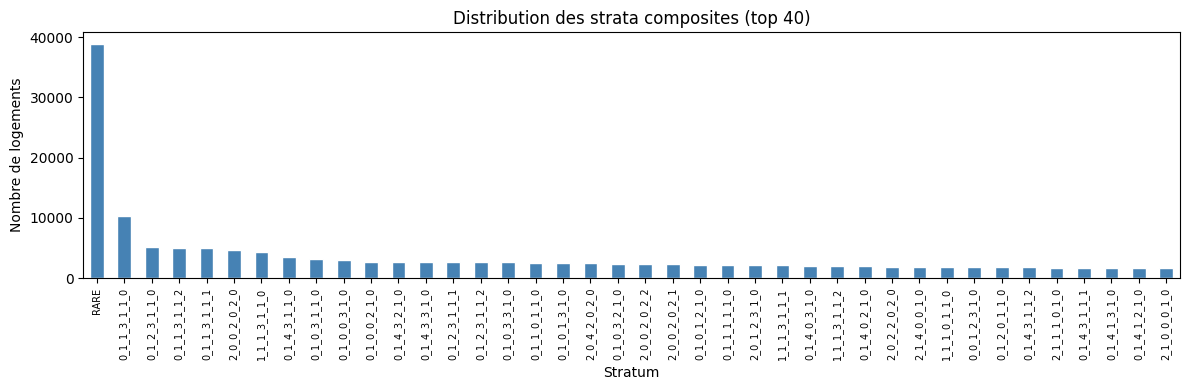

Strata couverts : 1367
Min / Médiane / Max : 54 / 182 / 38870


In [22]:
# ── Visualisation de la distribution des strata ───────────────────────────────
counts_final = stratum_final.value_counts().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
top_n = 40
counts_final.head(top_n).plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set(title=f'Distribution des strata composites (top {top_n})',
       xlabel='Stratum', ylabel='Nombre de logements')
ax.tick_params(axis='x', rotation=90, labelsize=7)
plt.tight_layout()
plt.show()

print(f'Strata couverts : {stratum_final.nunique()}')
print(f'Min / Médiane / Max : {counts_final.min()} / {counts_final.median():.0f} / {counts_final.max()}')

---
## 6. Split Train / Test stratifié

In [23]:
idx = np.arange(len(X))

idx_train, idx_test = train_test_split(
    idx,
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify     = stratum_final.values,
)

print(f'Train : {len(idx_train):,} ({len(idx_train)/len(X)*100:.1f}%)')
print(f'Test  : {len(idx_test):,}  ({len(idx_test)/len(X)*100:.1f}%)')

Train : 439,976 (80.0%)
Test  : 109,995  (20.0%)


In [24]:
# ── Validation de l'équilibre ─────────────────────────────────────────────────
# Pour chaque stratum, comparer la proportion train vs test

strat_train = stratum_final.iloc[idx_train].value_counts(normalize=True).rename('train')
strat_test  = stratum_final.iloc[idx_test].value_counts(normalize=True).rename('test')

df_check = pd.concat([strat_train, strat_test], axis=1).dropna()
df_check['diff_abs'] = (df_check['train'] - df_check['test']).abs()

print(f'Écart max train/test par stratum : {df_check["diff_abs"].max():.4f}')
print(f'Écart moyen                      : {df_check["diff_abs"].mean():.4f}')
print()
print('Top 10 strata les plus déséquilibrés :')
print(df_check.sort_values('diff_abs', ascending=False).head(10).to_string())

Écart max train/test par stratum : 0.0000
Écart moyen                      : 0.0000

Top 10 strata les plus déséquilibrés :
                  train      test  diff_abs
stratum                                    
1_1_1_3_1_1_2  0.003666  0.003673  0.000007
0_1_4_0_3_1_0  0.003793  0.003800  0.000007
2_0_0_2_0_2_2  0.004230  0.004237  0.000007
0_1_2_3_1_1_1  0.004739  0.004746  0.000007
0_1_4_3_1_1_0  0.006330  0.006337  0.000007
0_1_1_3_1_1_0  0.018812  0.018819  0.000007
2_0_2_2_0_2_0  0.003496  0.003491  0.000005
1_1_1_0_1_1_0  0.003405  0.003400  0.000005
0_1_4_3_1_1_2  0.003250  0.003246  0.000005
0_1_0_3_1_1_2  0.002814  0.002809  0.000005


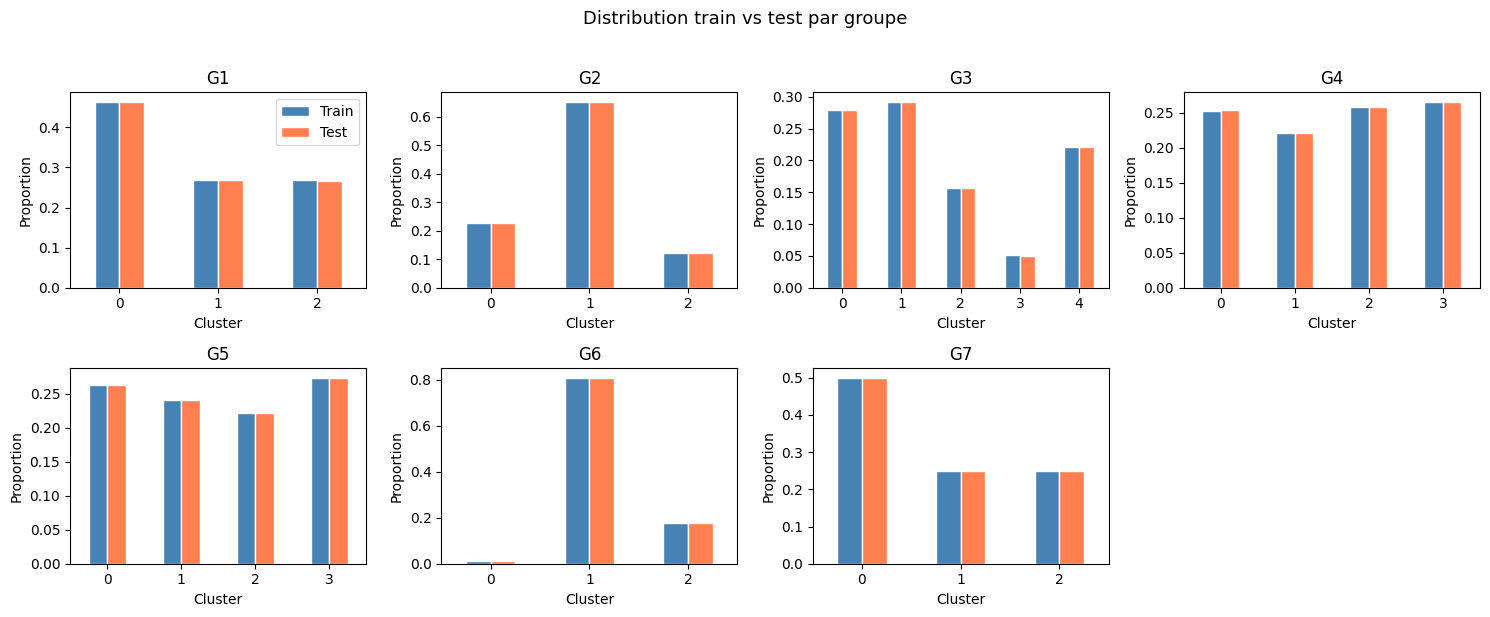

In [25]:
# ── Validation par groupe ─────────────────────────────────────────────────────
# Chaque cluster de chaque groupe doit être ~ 80 / 20 dans train / test

fig, axes = plt.subplots(2, 4, figsize=(15, 6))
axes = axes.flatten()

for ax, (gname, labels) in zip(axes, labels_all.items()):
    s = pd.Series(labels)
    train_dist = s.iloc[idx_train].value_counts(normalize=True).sort_index()
    test_dist  = s.iloc[idx_test].value_counts(normalize=True).sort_index()
    df_g = pd.DataFrame({'Train': train_dist, 'Test': test_dist})
    df_g.plot(kind='bar', ax=ax, color=['steelblue','coral'],
              edgecolor='white', legend=(gname == 'G1'))
    ax.set(title=gname, xlabel='Cluster', ylabel='Proportion')
    ax.tick_params(axis='x', rotation=0)

axes[-1].set_visible(False)
plt.suptitle('Distribution train vs test par groupe', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

---
## 7. Sauvegarde

In [26]:
# Indices
np.save(DATA_PROCESSED / 'idx_train.npy', idx_train)
np.save(DATA_PROCESSED / 'idx_test.npy',  idx_test)

# Labels de cluster par groupe + stratum final
df_labels['stratum_final'] = stratum_final.values
df_labels.to_parquet(DATA_PROCESSED / 'cluster_labels.parquet', index=False)

print('Sauvegardé :')
print(f'  idx_train.npy       → {len(idx_train):,} indices')
print(f'  idx_test.npy        → {len(idx_test):,} indices')
print(f'  cluster_labels.parquet → {df_labels.shape}')

Sauvegardé :
  idx_train.npy       → 439,976 indices
  idx_test.npy        → 109,995 indices
  cluster_labels.parquet → (549971, 9)


In [27]:
# ── Vérification rapide du split ──────────────────────────────────────────────
X_train = X.iloc[idx_train]
X_test  = X.iloc[idx_test]
Y_train = Y.iloc[idx_train]
Y_test  = Y.iloc[idx_test]

print('Split final :')
print(f'  X_train : {X_train.shape}  |  X_test : {X_test.shape}')
print(f'  Y_train : {Y_train.shape}  |  Y_test : {Y_test.shape}')
print()
print('Comparaison moyenne des cibles (train vs test) :')
comp = pd.DataFrame({'Train': Y_train.mean(), 'Test': Y_test.mean()})
comp['Diff %'] = ((comp['Test'] - comp['Train']) / comp['Train'] * 100).round(2)
print(comp.to_string())

Split final :
  X_train : (439976, 110)  |  X_test : (109995, 110)
  Y_train : (439976, 5)  |  Y_test : (109995, 5)

Comparaison moyenne des cibles (train vs test) :
                                                       Train          Test  Diff %
out.electricity.total.energy_consumption..kwh   11757.440060  11748.208457   -0.08
out.natural_gas.total.energy_consumption..kwh   10600.022782  10562.245742   -0.36
out.fuel_oil.total.energy_consumption..kwh       1285.944955   1259.816756   -2.03
out.propane.total.energy_consumption..kwh        1100.928087   1114.301773    1.21
out.emissions.total.lrmer_mid_case_25..co2e_kg   5430.672643   5413.585672   -0.31
